[2026-07-10 Fiddler](https://thefiddler.substack.com/p/can-you-power-up-the-hill)
====================

Fiddler
-------
Seems like a straightforward linear equation.

In [1]:
solve(300/(60*sin(x)+10) == 325/(80*sin(x)+10), x)

[x == arcsin(1/18)]

In [2]:
tan(arcsin(1/18)), numerical_approx(tan(arcsin(1/18)))

(1/323*sqrt(323), 0.0556414884074657)

Looks like the equal speed grade is $1/\sqrt{323}$, approximately 5.564%.

Extra credit
------------
Let $g$ be the maximum gradient.  Let $x$ be the horizontal position,
where $x = 0$ is the base and $x = \pi$ is the peak.  The elevation will
be $y = -g\cos x$.

The inclination $\tan\theta = dy/dx = g\sin x$, so
$\sin\theta = \frac{g\sin x}{\sqrt{1 + g^2\sin^2 x}}$.

The square of the speed is

$$
    v^2 = \left(\frac{dx}{dt}\right)^2 + \left(\frac{dy}{dt}\right)^2
        = \left(\frac{dx}{dt}\right)^2\left(1 + \left(\frac{dy}{dx}\right)^2\right)
        = \left(\frac{dx}{dt}\right)^2(1 + g^2\sin^2 x)
$$

then

$$ \frac{dx}{dt} = \frac{P}{(m\sin\theta+10)\sqrt{1 + g^2\sin^2 x}} = \frac{P}{mg\sin x+10\sqrt{1+g^2\sin^2 x}}$$

The time to climb the hill is then

$$ \frac1P\int_0^\pi dx\,\left(mg\sin x + 10\sqrt{1+g^2\sin^2x}\right) $$

In [3]:
g,m,P = var("g,m,P")
assume(g, "real")
assume(g > 0)
t = (1/P)*integral(m*g*sin(x)+10*sqrt(1+g^2*sin(x)^2),x,0,pi)
t

No checks were made for singular points of antiderivative -sageVARg*sageVARm*cos(sageVARx) for definite integration in [0,pi]


integrate(g*m*sin(x) + 10*sqrt(g^2*sin(x)^2 + 1), x, 0, pi)/P

In [4]:
t1 = (1/P)*integral(m*g*sin(x),x,0,pi)
t2 = (1/P)*integral(10*sqrt(1+g^2*sin(x)^2),x,0,pi)
t1,t2

(2*g*m/P, integrate(10*sqrt(g^2*sin(x)^2 + 1), x, 0, pi)/P)

In [5]:
t2 = (10/P)*elliptic_e(pi,-g^2)
t = t1 + t2
t

2*g*m/P + 10*elliptic_e(pi, -g^2)/P

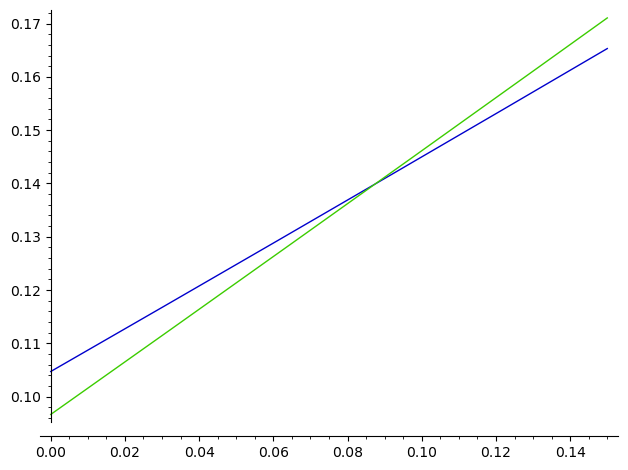

In [6]:
plot([t.subs(P=300,m=60),t.subs(P=325,m=80)], g, 0, 0.15)

In [7]:
solve(t.subs(P=300,m=60)==t.subs(P=325,m=80),g)

[g == 1/36*elliptic_e(pi, -g^2)]

In [8]:
g_eq = find_root(t.subs(P=300,m=60)-t.subs(P=325,m=80),0,0.15)
g_eq

0.0874330020767798

So the hill climb times are equal when the maximum grade is approximately 8.743%.

Further thoughts
----------------
For the fiddler, the answer is an average grade of $1/\sqrt{323} \approx 5.5564\%$
and an average inclination of $\arcsin(1/18) \approx \arcsin 0.05556$.

For the extra credit hill with maximum grade $g$, the average grade is
$2g/\pi \approx 5.5566\%$, and the average inclination is
$\arcsin(2g/E(\pi\,|\,-g^2)) \approx \arcsin 0.05556$.

In [9]:
numerical_approx(1/sqrt(323)), numerical_approx(2*g_eq/pi)

(0.0556414884074657, 0.0556615778795338)

In [10]:
numerical_approx(1/18), numerical_approx(g_eq*2/elliptic_e(pi, -g_eq^2))

(0.0555555555555556, 0.0555555555555555)

So the average grade and average inclination of the equal time hill of the extra credit
are very close to the equal speed grade and inclination of the fiddler.

In my cycling experience, an average grade of around 5.5% can be a tough climb, but
is not particularly steep, even if the maximum grade is around 9%.  In the 2010s, I
regularly rode up a nearly 3 mile climb with an average grade of nearly 10%, Jamison
Creek Road, and, less often, a nearly 4 mile climb with an average grade of nearly
10%, Alba Road.  Those are tough and steep climbs.  These days, the steepest climb
I regularly ride is Miramar Drive in Santa Cruz from Escalona to Alta Vista, which
averages about 14% with a maximum grade of more than 20% over about 500ft, so it's
pretty short.